# Análisis de sentimiento de los tweets

Recursos externos: Opinion Lexicon de Hu y Liu (2004) y VADER (Hutto y Gilbert, 2014), ambos
en `nltk`.

In [1]:
import ssl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from pathlib import Path

try:
    import certifi
    ssl._create_default_https_context = lambda *a, **k: ssl.create_default_context(cafile=certifi.where())
except Exception:
    pass

for pkg, path in [
    ("vader_lexicon", "sentiment/vader_lexicon"),
    ("opinion_lexicon", "corpora/opinion_lexicon"),
    ("punkt", "tokenizers/punkt"),
    ("punkt_tab", "tokenizers/punkt_tab"),
]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg, quiet=True)

from nltk.corpus import opinion_lexicon
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import mannwhitneyu

pd.set_option("display.max_colwidth", 140)
plt.rcParams["figure.dpi"] = 110
OUT = Path("../output"); OUT.mkdir(exist_ok=True)


## 1. Carga de los datos

In [2]:
df = pd.read_csv("../data/train_clean.csv")
print("Filas:", len(df))
df[["text", "text_clean", "target"]].head()


Filas: 7484


,text,text_clean,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,our deeds are the reason of this earthquake may allah forgive us all,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place orders are expected,1
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfires evacuation orders in california,1
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent this photo from ruby alaska as smoke from wildfires pours into a school,1


## 2. Conteo de palabras positivas / negativas / neutras (léxico de Hu y Liu)

Sobre `text_clean` (limpio, sin lematizar). Clasificación del tweet: positivo si
`n_pos - n_neg > 0`, negativo si `< 0`, neutral si `= 0`.

In [3]:
POS = set(opinion_lexicon.positive())
NEG = set(opinion_lexicon.negative())
print(f"Palabras positivas en el léxico: {len(POS):,}")
print(f"Palabras negativas en el léxico: {len(NEG):,}")

def contar_sentimiento(texto):
    tokens = [t for t in word_tokenize(str(texto).lower()) if t.isalpha()]
    n_pos = sum(t in POS for t in tokens)
    n_neg = sum(t in NEG for t in tokens)
    n_tot = len(tokens)
    return pd.Series({"n_palabras": n_tot,
                      "n_pos": n_pos,
                      "n_neg": n_neg,
                      "n_neu": n_tot - n_pos - n_neg})

conteos = df["text_clean"].apply(contar_sentimiento)
df = pd.concat([df, conteos], axis=1)

df["score_lex"] = df["n_pos"] - df["n_neg"]
df["polaridad_lex"] = df["score_lex"] / df["n_palabras"].replace(0, np.nan)
df["polaridad_lex"] = df["polaridad_lex"].fillna(0)

def clasificar_lex(s):
    if s > 0:  return "positivo"
    if s < 0:  return "negativo"
    return "neutral"

df["sentimiento_lex"] = df["score_lex"].apply(clasificar_lex)
df[["text_clean", "n_pos", "n_neg", "n_neu", "score_lex", "sentimiento_lex"]].head(10)


Palabras positivas en el léxico: 2,006
Palabras negativas en el léxico: 4,783


,text_clean,n_pos,n_neg,n_neu,score_lex,sentimiento_lex
0,our deeds are the reason of this earthquake may allah forgive us all,0,0,13,0,neutral
1,forest fire near la ronge sask canada,0,0,7,0,neutral
2,all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place orders are expected,0,0,22,0,neutral
3,people receive wildfires evacuation orders in california,0,0,7,0,neutral
4,just got sent this photo from ruby alaska as smoke from wildfires pours into a school,0,1,15,-1,negativo
5,rockyfire update california hwy closed in both directions due to lake county fire cafire wildfires,0,0,15,0,neutral
6,flood disaster heavy rain causes flash flooding of streets in manitou colorado springs areas,0,1,13,-1,negativo
7,i am on top of the hill and i can see a fire in the woods,1,0,15,1,positivo
8,theres an emergency evacuation happening now in the building across the street,0,1,11,-1,negativo
9,i am afraid that the tornado is coming to our area,0,1,10,-1,negativo


In [4]:
# Palabras que el léxico marca en un tweet
def mostrar_palabras(texto):
    toks = [t for t in word_tokenize(str(texto).lower()) if t.isalpha()]
    return pd.DataFrame({
        "palabra": toks,
        "tipo": ["positiva" if t in POS else "negativa" if t in NEG else "neutra" for t in toks],
    })

print(df.loc[5, "text"])
mostrar_palabras(df.loc[5, "text_clean"])


#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires


,palabra,tipo
0,rockyfire,neutra
1,update,neutra
2,california,neutra
3,hwy,neutra
4,closed,neutra
5,in,neutra
6,both,neutra
7,directions,neutra
8,due,neutra
9,to,neutra


In [5]:
dist_lex = df["sentimiento_lex"].value_counts().reindex(["negativo", "neutral", "positivo"])
print(dist_lex)
print((dist_lex / len(df) * 100).round(1).astype(str) + " %")


sentimiento_lex
negativo    3523
neutral     2890
positivo    1071
Name: count, dtype: int64
sentimiento_lex
negativo    47.1 %
neutral     38.6 %
positivo    14.3 %
Name: count, dtype: str


## 3. Puntaje de sentimiento con VADER

Sobre el texto original `text` (aprovecha mayúsculas y puntuación). Umbrales estándar:
`compound >= 0.05` positivo, `<= -0.05` negativo, en medio neutral.

In [6]:
sia = SentimentIntensityAnalyzer()

vscores = df["text"].apply(sia.polarity_scores).apply(pd.Series)
vscores = vscores.rename(columns={"neg": "vader_neg", "neu": "vader_neu",
                                  "pos": "vader_pos", "compound": "vader_compound"})
df = pd.concat([df, vscores], axis=1)

def clasificar_vader(c):
    if c >= 0.05:  return "positivo"
    if c <= -0.05: return "negativo"
    return "neutral"

df["sentimiento_vader"] = df["vader_compound"].apply(clasificar_vader)
df[["text", "vader_compound", "sentimiento_vader"]].head(10)


,text,vader_compound,sentimiento_vader
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,0.2732,positivo
1,Forest fire near La Ronge Sask. Canada,-0.3400,negativo
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,-0.2960,negativo
3,"13,000 people receive #wildfires evacuation orders in California",0.0000,neutral
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,0.0000,neutral
5,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,-0.3400,negativo
6,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",0.0000,neutral
7,I'm on top of the hill and I can see a fire in the woods...,-0.1531,negativo
8,There's an emergency evacuation happening now in the building across the street,-0.3818,negativo
9,I'm afraid that the tornado is coming to our area...,0.0000,neutral


In [7]:
dist_vader = df["sentimiento_vader"].value_counts().reindex(["negativo", "neutral", "positivo"])
print(dist_vader)
print((dist_vader / len(df) * 100).round(1).astype(str) + " %")


sentimiento_vader
negativo    3641
neutral     1978
positivo    1865
Name: count, dtype: int64
sentimiento_vader
negativo    48.7 %
neutral     26.4 %
positivo    24.9 %
Name: count, dtype: str


### 3.1 Acuerdo entre los dos métodos

In [8]:
cruce = pd.crosstab(df["sentimiento_lex"], df["sentimiento_vader"],
                    rownames=["Hu & Liu (conteo)"], colnames=["VADER"])
acuerdo = (df["sentimiento_lex"] == df["sentimiento_vader"]).mean()
print(cruce)
print(f"\nCoinciden en el {acuerdo*100:.1f} % de los tweets")


VADER              negativo  neutral  positivo
Hu & Liu (conteo)                             
negativo               2545      585       393
neutral                 927     1245       718
positivo                169      148       754

Coinciden en el 60.7 % de los tweets


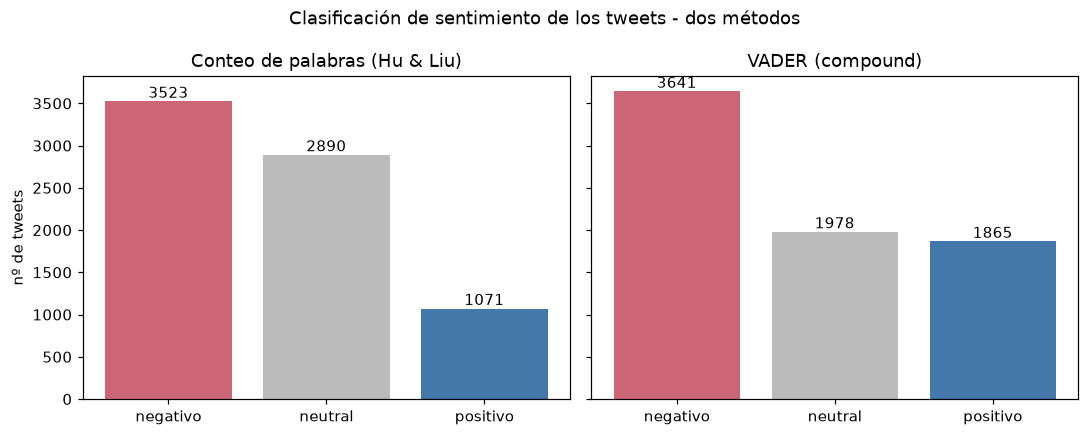

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
colores = {"negativo": "#cc6677", "neutral": "#bbbbbb", "positivo": "#4477aa"}
for ax, serie, titulo in [
    (axes[0], dist_lex, "Conteo de palabras (Hu & Liu)"),
    (axes[1], dist_vader, "VADER (compound)"),
]:
    ax.bar(serie.index, serie.values, color=[colores[i] for i in serie.index])
    ax.bar_label(ax.containers[0])
    ax.set_title(titulo)
axes[0].set_ylabel("nº de tweets")
fig.suptitle("Clasificación de sentimiento de los tweets - dos métodos")
plt.tight_layout(); plt.savefig(OUT / "sentimiento_distribucion.png"); plt.show()


## 4. Los 10 tweets más negativos y los 10 más positivos

Ordenados por el `compound` de VADER. `target`: 1 = desastre real, 0 = no desastre.

In [10]:
cols_show = ["text", "target", "vader_compound", "n_pos", "n_neg", "score_lex"]

top_neg = df.nsmallest(10, "vader_compound")[cols_show].reset_index(drop=True)
top_neg.index += 1
print("10 tweets más negativos")
top_neg


10 tweets más negativos


,text,target,vader_compound,n_pos,n_neg,score_lex
1,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?,0,-0.9883,0,13,-13
2,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead\nThis is ridiculous,1,-0.9686,0,5,-5
3,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o...,1,-0.9623,0,5,-5
4,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp,1,-0.9595,0,4,-4
5,17 killed in SÛªArabia mosque suicide bombing\n\nA suicide bomber attacked a mosque in Aseer south-western Saudi... http://t.co/pMTQhiVsXX,1,-0.9552,0,3,-3
6,at the lake \n*sees a dead fish*\nme: poor little guy i wonder what happened\nashley: idk maybe it drowned\n wtf ????????,0,-0.9549,1,2,-1
7,illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Santa Maria CA Woman Had Prior Offenses http://t.co/MqP4h...,1,-0.9538,0,4,-4
8,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violence Drugs Cartel Cocaine Marijuana Heroine Kidnap Bust,1,-0.9524,1,7,-6
9,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on that day in September there,1,-0.9500,0,5,-5
10,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the world. You create terrorist you sponsor terrorist.,1,-0.9493,0,1,-1


In [11]:
top_pos = df.nlargest(10, "vader_compound")[cols_show].reset_index(drop=True)
top_pos.index += 1
print("10 tweets más positivos")
top_pos


10 tweets más positivos


,text,target,vader_compound,n_pos,n_neg,score_lex
1,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at http://t.co/3GEROQ49o1\nI would Love Love Love!! To...,0,0.9730,4,0,4
2,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're okay!!!,0,0.9564,2,0,2
3,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul return to bliss.,1,0.9471,3,0,3
4,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.,0,0.9423,5,1,4
5,Maaaaan I love Love Without Tragedy by @rihanna I wish she made the whole song,0,0.9394,2,1,1
6,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please Favorite &amp; Share,0,0.9376,3,0,3
7,@Raishimi33 :) well I think that sounds like a fine plan where little derailment is possible so I applaud you :),1,0.9356,4,0,4
8,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.,0,0.9345,2,0,2
9,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2 movies. Let's hope for the good. There's hope ??????,0,0.9344,1,0,1
10,Super sweet and beautiful :) https://t.co/TUi9uwBvVp,0,0.9300,3,0,3


In [12]:
print("Categoría de los 10 más NEGATIVOS:")
print(top_neg["target"].value_counts().rename({0: "no desastre", 1: "desastre real"}))
print("\nCategoría de los 10 más POSITIVOS:")
print(top_pos["target"].value_counts().rename({0: "no desastre", 1: "desastre real"}))


Categoría de los 10 más NEGATIVOS:
target
desastre real    8
no desastre      2
Name: count, dtype: int64

Categoría de los 10 más POSITIVOS:
target
no desastre      8
desastre real    2
Name: count, dtype: int64


## 5. ¿Son los tweets de desastre real más negativos que los otros?

In [13]:
resumen = df.groupby("target").agg(
    n_tweets=("text", "size"),
    vader_compound_medio=("vader_compound", "mean"),
    polaridad_lex_media=("polaridad_lex", "mean"),
    palabras_neg_media=("n_neg", "mean"),
    palabras_pos_media=("n_pos", "mean"),
).round(3)
resumen.index = ["0 - no desastre", "1 - desastre real"]
resumen


,n_tweets,vader_compound_medio,polaridad_lex_media,palabras_neg_media,palabras_pos_media
0 - no desastre,4297,-0.061,-0.033,0.812,0.462
1 - desastre real,3187,-0.265,-0.064,1.019,0.234


In [14]:
pct_neg = pd.crosstab(df["target"], df["sentimiento_vader"], normalize="index").mul(100).round(1)
pct_neg.index = ["0 - no desastre", "1 - desastre real"]
print("Distribución de sentimiento (VADER) dentro de cada categoría, en %:")
print(pct_neg)

pct_neg_lex = pd.crosstab(df["target"], df["sentimiento_lex"], normalize="index").mul(100).round(1)
pct_neg_lex.index = ["0 - no desastre", "1 - desastre real"]
print("\nMismo cruce con el conteo de palabras (Hu & Liu):")
print(pct_neg_lex)


Distribución de sentimiento (VADER) dentro de cada categoría, en %:
sentimiento_vader  negativo  neutral  positivo
0 - no desastre        42.5     26.1      31.4
1 - desastre real      57.0     26.9      16.2

Mismo cruce con el conteo de palabras (Hu & Liu):
sentimiento_lex    negativo  neutral  positivo
0 - no desastre        41.3     40.0      18.7
1 - desastre real      54.8     36.8       8.4


In [15]:
c0 = df.loc[df.target == 0, "vader_compound"]
c1 = df.loc[df.target == 1, "vader_compound"]
u, p = mannwhitneyu(c1, c0, alternative="less")   # H1: los de desastre son MÁS negativos
print(f"Mediana compound: no desastre: {c0.median():.3f}   desastre: {c1.median():.3f}")
print(f"Media   compound: no desastre: {c0.mean():.3f}   desastre: {c1.mean():.3f}")
print(f"Mann-Whitney U = {u:,.0f}   p-value = {p:.3e}")
print("Significativo (los de desastre son más negativos)" if p < 0.05
      else "No hay evidencia de que sean más negativos")


Mediana compound: no desastre: 0.000   desastre: -0.312
Media   compound: no desastre: -0.061   desastre: -0.265
Mann-Whitney U = 5,141,874   p-value = 1.346e-77
Significativo (los de desastre son más negativos)


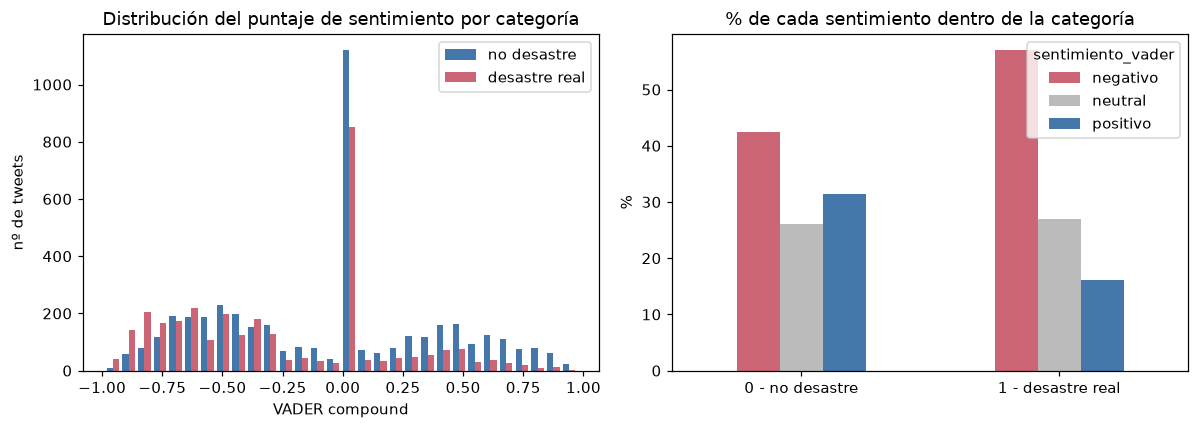

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist([c0, c1], bins=30, label=["no desastre", "desastre real"],
             color=["#4477aa", "#cc6677"])
axes[0].set_xlabel("VADER compound"); axes[0].set_ylabel("nº de tweets")
axes[0].set_title("Distribución del puntaje de sentimiento por categoría")
axes[0].legend()

pct_neg[["negativo", "neutral", "positivo"]].plot.bar(
    ax=axes[1], color=[colores["negativo"], colores["neutral"], colores["positivo"]])
axes[1].set_title("% de cada sentimiento dentro de la categoría")
axes[1].set_ylabel("%"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.savefig(OUT / "sentimiento_por_categoria.png"); plt.show()


## 6. Variable de negatividad y guardado del dataset

`negatividad = (1 - vader_compound) / 2`, en escala [0, 1]. Se guarda `data/train_sentiment.csv` para el punto 10.

In [17]:
df["negatividad"] = ((1 - df["vader_compound"]) / 2).round(4)

nuevas = ["n_palabras", "n_pos", "n_neg", "n_neu", "score_lex", "polaridad_lex",
          "sentimiento_lex", "vader_neg", "vader_neu", "vader_pos", "vader_compound",
          "sentimiento_vader", "negatividad"]

df.to_csv("../data/train_sentiment.csv", index=False)
print("Guardado data/train_sentiment.csv:", df.shape)
df[["text", "target"] + nuevas].head()


Guardado data/train_sentiment.csv: (7484, 23)


,text,target,n_palabras,n_pos,n_neg,n_neu,score_lex,polaridad_lex,sentimiento_lex,vader_neg,vader_neu,vader_pos,vader_compound,sentimiento_vader,negatividad
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,13,0,0,13,0,0.0000,neutral,0.000,0.851,0.149,0.2732,positivo,0.3634
1,Forest fire near La Ronge Sask. Canada,1,7,0,0,7,0,0.0000,neutral,0.286,0.714,0.000,-0.3400,negativo,0.6700
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1,22,0,0,22,0,0.0000,neutral,0.095,0.905,0.000,-0.2960,negativo,0.6480
3,"13,000 people receive #wildfires evacuation orders in California",1,7,0,0,7,0,0.0000,neutral,0.000,1.000,0.000,0.0000,neutral,0.5000
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,16,0,1,15,-1,-0.0625,negativo,0.000,1.000,0.000,0.0000,neutral,0.5000
